# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

In [2]:
df = pd.read_csv('../data/am_pm.csv')

In [3]:
df

,date,am,pm,target,predict
0,2020-04-17,21,2,workday,1
1,2020-04-18,1,68,weekend,0
2,2020-04-19,18,15,weekend,0
3,2020-04-20,2,23,workday,0
4,2020-04-21,0,25,workday,0
5,2020-04-22,0,28,workday,0
6,2020-04-23,10,33,workday,0
7,2020-04-24,2,14,workday,0
8,2020-04-25,30,74,weekend,0
9,2020-04-26,28,233,weekend,0


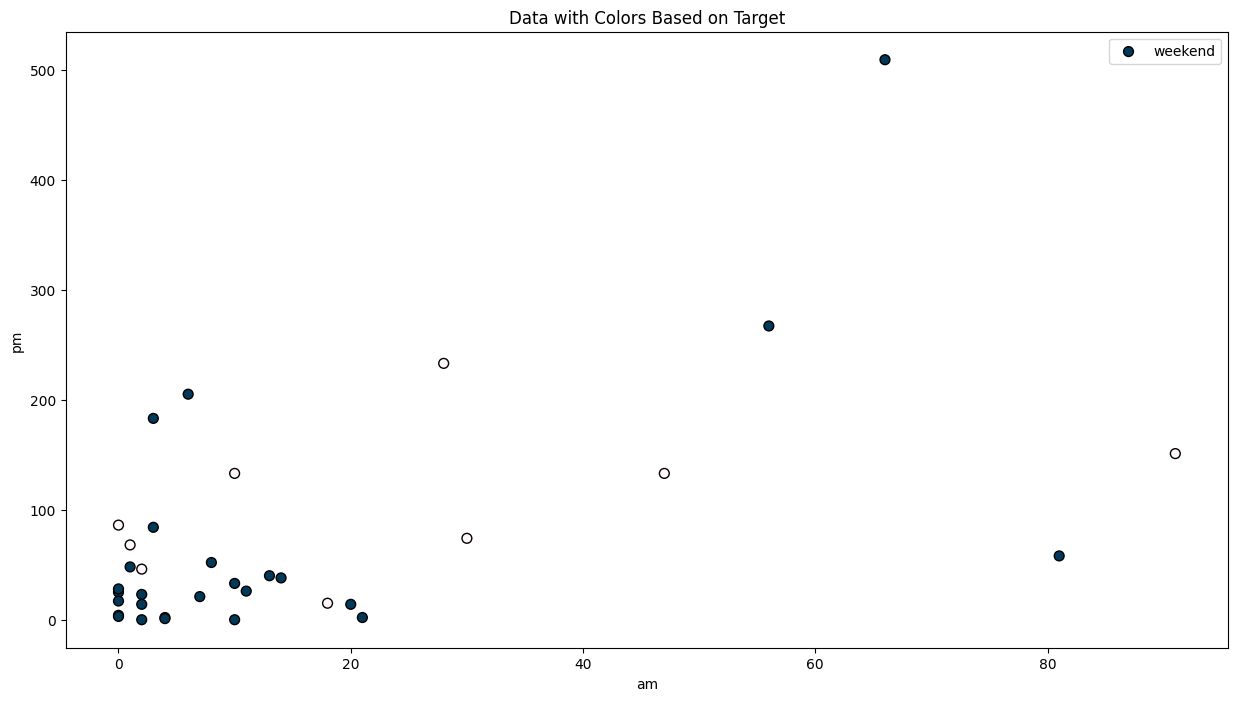

In [4]:
plt.figure(figsize=(15, 8))
plt.scatter(df['am'], df['pm'], c=df['target'].map({'workday': 1, 'weekend': 0}), cmap='PuBu', edgecolor='k', s=50, label='weekend')
plt.xlabel('am')
plt.ylabel('pm')
plt.title('Data with Colors Based on Target')
plt.legend()
plt.show()

In [5]:
X = df[['am', 'pm']]

In [6]:
y = df['target'].apply(lambda x: 1 if x == 'weekend' else 0)

In [7]:
model = LogisticRegression(random_state=21, fit_intercept=False)

In [8]:
model.fit(X, y)

LogisticRegression(fit_intercept=False, random_state=21)

In [9]:
xx, yy = np.meshgrid(np.linspace(X['am'].min() - 1, X['am'].max() + 1, 500), np.linspace(X['pm'].min() - 1, X['pm'].max() + 1, 500))

In [10]:
grid = np.c_[xx.ravel(), yy.ravel()]

In [11]:
grid = pd.DataFrame(grid, columns=['am', 'pm'])

In [12]:
probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)

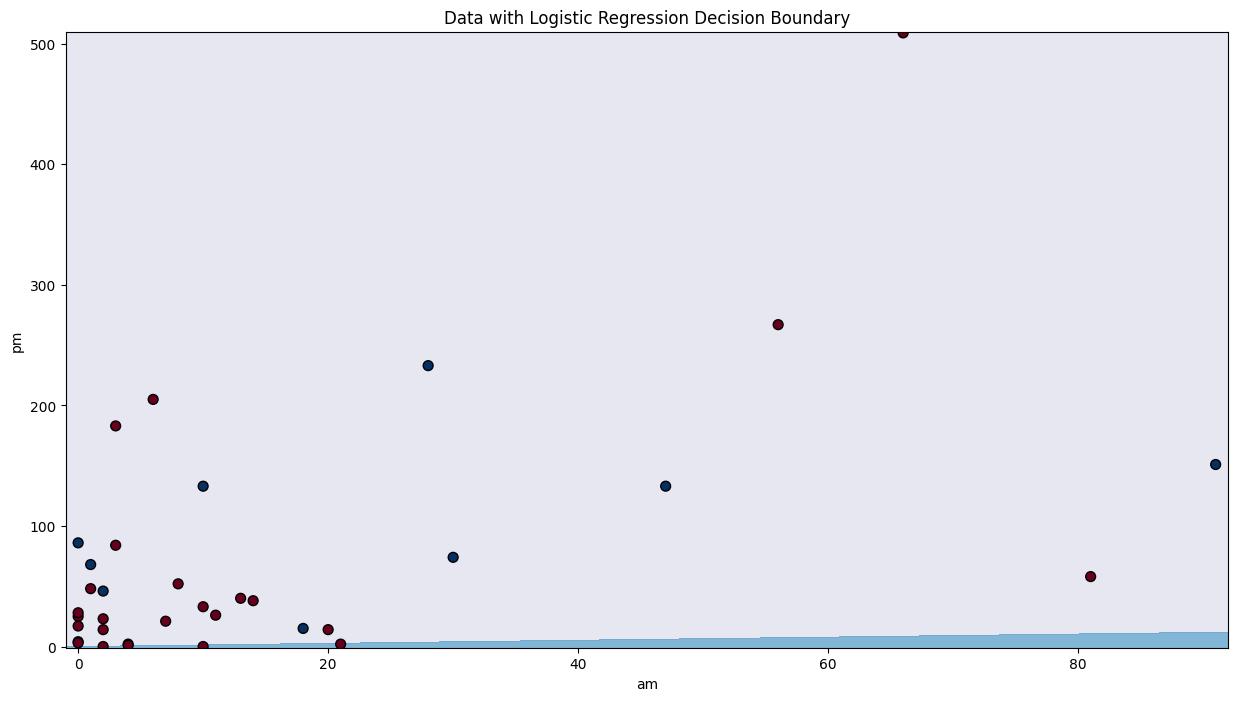

In [13]:
plt.figure(figsize=(15, 8))
plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], cmap='PuBu', alpha=0.5)
plt.scatter(X['am'], X['pm'], c=y, cmap='RdBu', edgecolor='k', s=50)
plt.xlabel('am')
plt.ylabel('pm')
plt.title('Data with Logistic Regression Decision Boundary')
plt.show()

In [14]:
y_pred = model.predict(X)

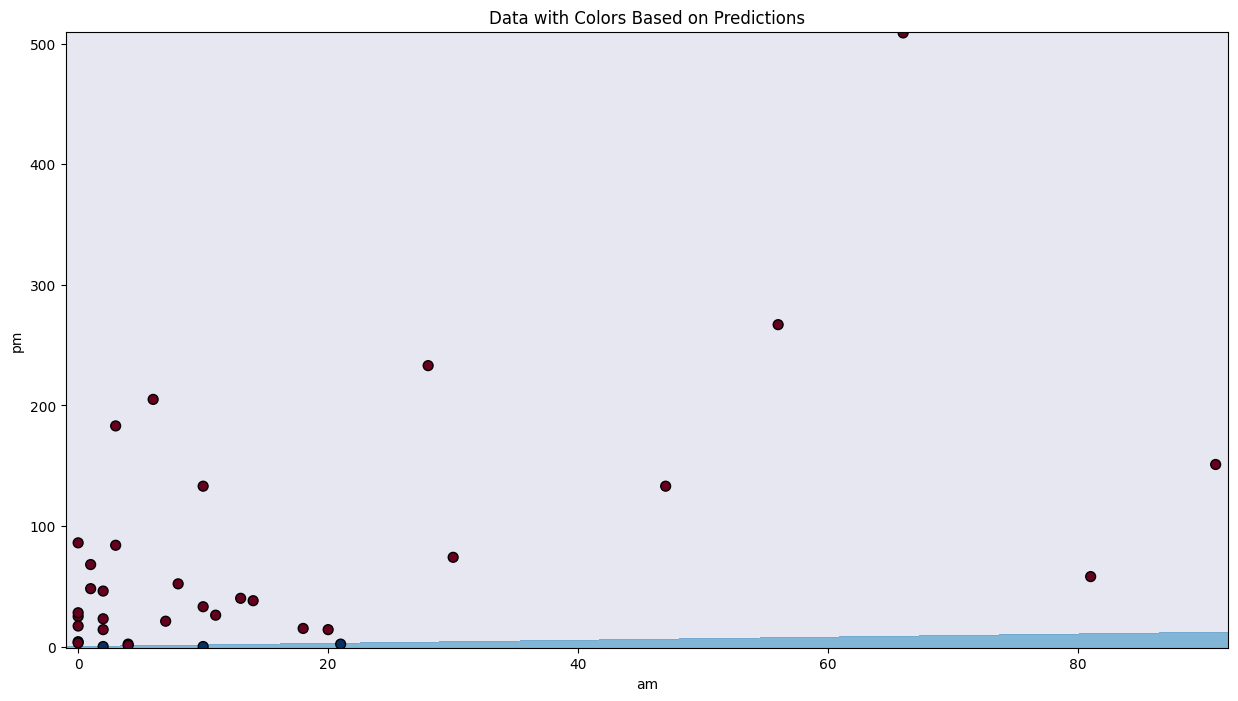

In [15]:
plt.figure(figsize=(15, 8))
plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], cmap='PuBu', alpha=0.5)
plt.scatter(X['am'], X['pm'], c=y_pred, cmap='RdBu', edgecolor='k', s=50)
plt.xlabel('am')
plt.ylabel('pm')
plt.title('Data with Colors Based on Predictions')
plt.show()

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
log_reg = LogisticRegression(random_state=21, fit_intercept=False)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(fit_intercept=False, random_state=21)

In [19]:
log_reg_pred = log_reg.predict(X_test_scaled)
log_reg_acc = accuracy_score(y_test, log_reg_pred)
print("Logistic Regression Accuracy:", log_reg_acc)

Logistic Regression Accuracy: 0.5714285714285714


In [20]:
most_common_class = y_train.value_counts().idxmax()
naive_acc = accuracy_score(y_test, [most_common_class] * len(y_test))
print("Naive Classifier Accuracy:", naive_acc)

Naive Classifier Accuracy: 0.8571428571428571


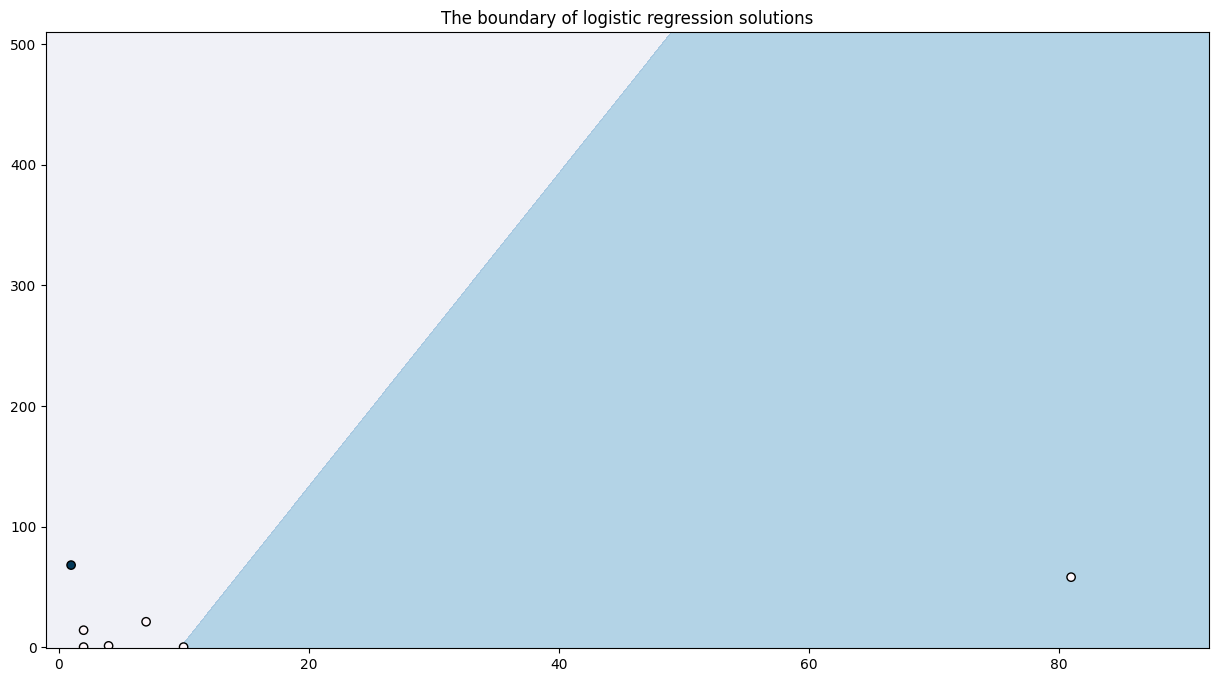

In [21]:
xx, yy = np.meshgrid(np.linspace(X['am'].min()-1, X['am'].max()+1, 500),
                     np.linspace(X['pm'].min()-1, X['pm'].max()+1, 500))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_df = pd.DataFrame(grid, columns=['am', 'pm'])
grid_scaled = scaler.transform(grid_df)

log_reg_probs = log_reg.predict_proba(grid_scaled)[:, 1].reshape(xx.shape)
plt.figure(figsize=(15, 8))
plt.contourf(xx, yy, log_reg_probs, levels=[0, 0.5, 1], cmap='PuBu', alpha=0.3)
plt.scatter(X_test['am'], X_test['pm'], c=y_test, cmap='PuBu', edgecolor='k')
plt.title('The boundary of logistic regression solutions')
plt.show()

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

In [22]:
X = df[['am', 'pm']]
y = df['target'].apply(lambda x: 1 if x == 'weekend' else 0)

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_kernel = None
best_accuracy = 0
best_model = None

for kernel in kernels:
    svc_model = SVC(kernel=kernel, probability=True, random_state=21)
    svc_model.fit(X_scaled, y)
    
    svc_pred = svc_model.predict(X_scaled)
    acc = accuracy_score(y, svc_pred)
    print(f"SVC with {kernel} kernel - Accuracy: {acc}")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_kernel = kernel
        best_model = svc_model

print(f"Best kernel: {best_kernel} with accuracy {best_accuracy}")

SVC with linear kernel - Accuracy: 0.7142857142857143
SVC with poly kernel - Accuracy: 0.7428571428571429
SVC with rbf kernel - Accuracy: 0.7428571428571429
SVC with sigmoid kernel - Accuracy: 0.6857142857142857
Best kernel: poly with accuracy 0.7428571428571429


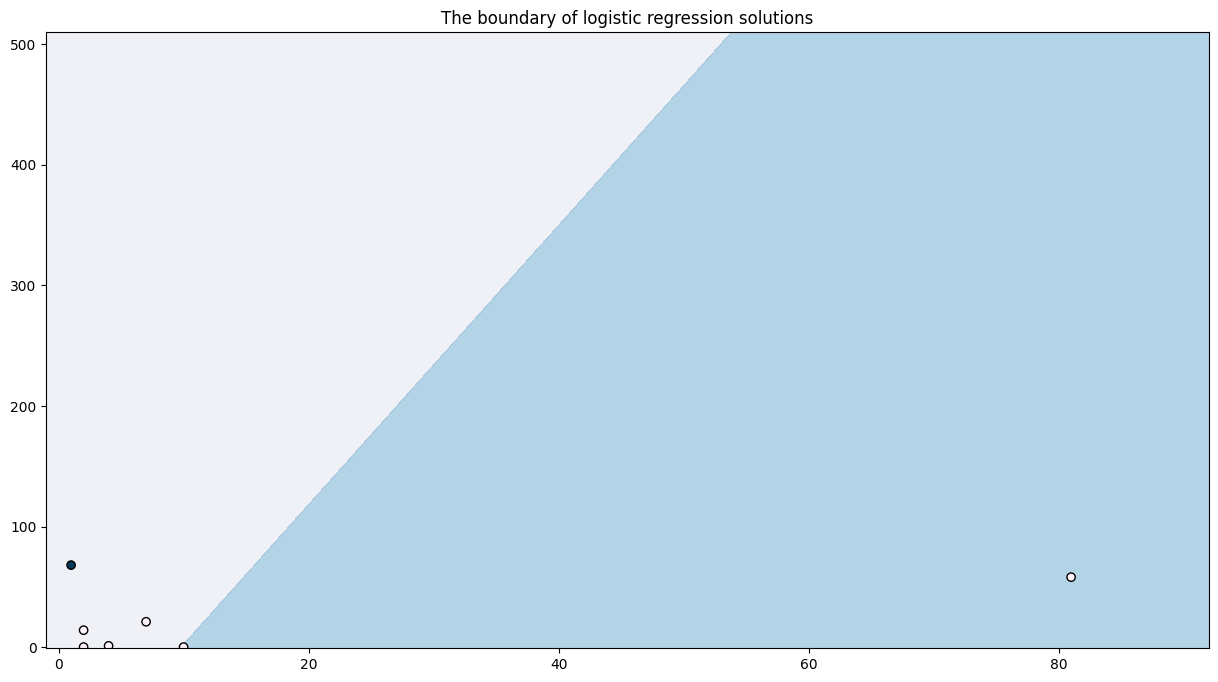

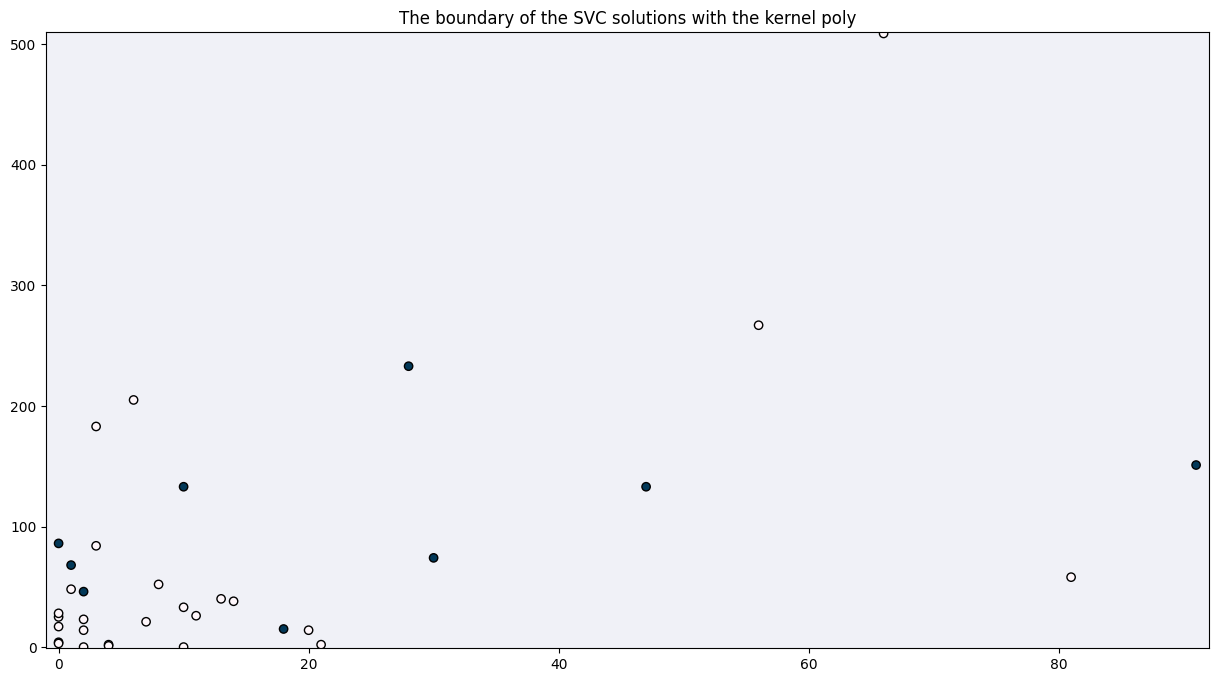

In [25]:
xx, yy = np.meshgrid(np.linspace(X['am'].min()-1, X['am'].max()+1, 500),
                     np.linspace(X['pm'].min()-1, X['pm'].max()+1, 500))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_df = pd.DataFrame(grid, columns=['am', 'pm'])
grid_scaled = scaler.transform(grid_df)

log_reg_probs = log_reg.predict_proba(grid_scaled)[:, 1].reshape(xx.shape)
plt.figure(figsize=(15, 8))
plt.contourf(xx, yy, log_reg_probs, levels=[0, 0.5, 1], cmap='PuBu', alpha=0.3)
plt.scatter(X_test['am'], X_test['pm'], c=y_test, cmap='PuBu', edgecolor='k')
plt.title('The boundary of logistic regression solutions')
plt.show()

xx, yy = np.meshgrid(np.linspace(X['am'].min()-1, X['am'].max()+1, 500),
                     np.linspace(X['pm'].min()-1, X['pm'].max()+1, 500))
grid_df = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['am', 'pm'])
grid_scaled = scaler.transform(grid_df)

svc_probs = best_model.predict_proba(grid_scaled)[:, 1].reshape(xx.shape)
plt.figure(figsize=(15, 8))
plt.contourf(xx, yy, svc_probs, levels=[0, 0.5, 1], cmap='PuBu', alpha=0.3)
plt.scatter(X['am'], X['pm'], c=y, cmap='PuBu', edgecolor='k')
plt.title(f'The boundary of the SVC solutions with the kernel {best_kernel}')
plt.show()

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [26]:
X = df[['am', 'pm']]
y = df['target'].apply(lambda x: 1 if x == 'weekend' else 0)

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
depth_values = [2, 4, 6, 8, 10]
best_depth = None
best_accuracy = 0
best_tree_model = None

for depth in depth_values:
    tree_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree_model.fit(X_scaled, y)
    
    tree_pred = tree_model.predict(X_scaled)
    acc = accuracy_score(y, tree_pred)
    print(f"Decision Tree with max_depth={depth} - Accuracy: {acc}")
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_depth = depth
        best_tree_model = tree_model

print(f"Best max_depth: {best_depth} with accuracy {best_accuracy}")

Decision Tree with max_depth=2 - Accuracy: 0.8571428571428571
Decision Tree with max_depth=4 - Accuracy: 0.9428571428571428
Decision Tree with max_depth=6 - Accuracy: 1.0
Decision Tree with max_depth=8 - Accuracy: 1.0
Decision Tree with max_depth=10 - Accuracy: 1.0
Best max_depth: 6 with accuracy 1.0


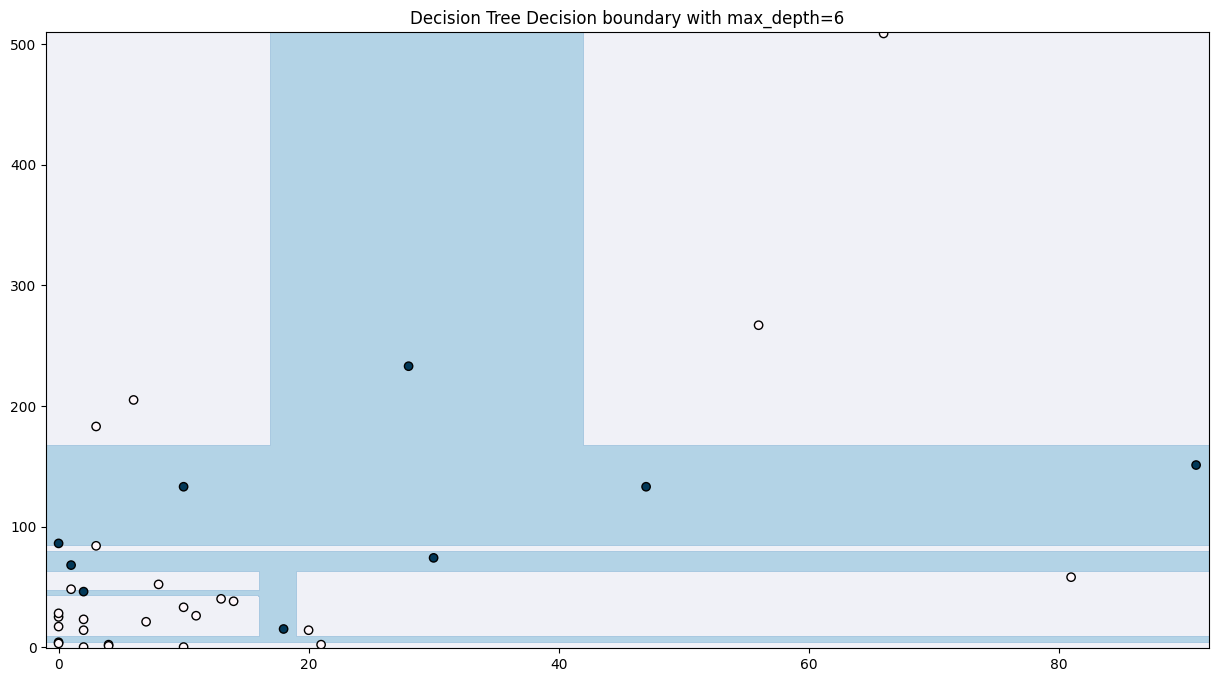

In [29]:
xx, yy = np.meshgrid(np.linspace(X['am'].min()-1, X['am'].max()+1, 500),
                     np.linspace(X['pm'].min()-1, X['pm'].max()+1, 500))
grid_df = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=['am', 'pm'])
grid_scaled = scaler.transform(grid_df)

tree_preds = best_tree_model.predict(grid_scaled).reshape(xx.shape)
plt.figure(figsize=(15, 8))
plt.contourf(xx, yy, tree_preds, levels=[0, 0.5, 1], cmap='PuBu', alpha=0.3)
plt.scatter(X['am'], X['pm'], c=y, cmap='PuBu', edgecolor='k')
plt.title(f'Decision Tree Decision boundary with max_depth={best_depth}')
plt.show()

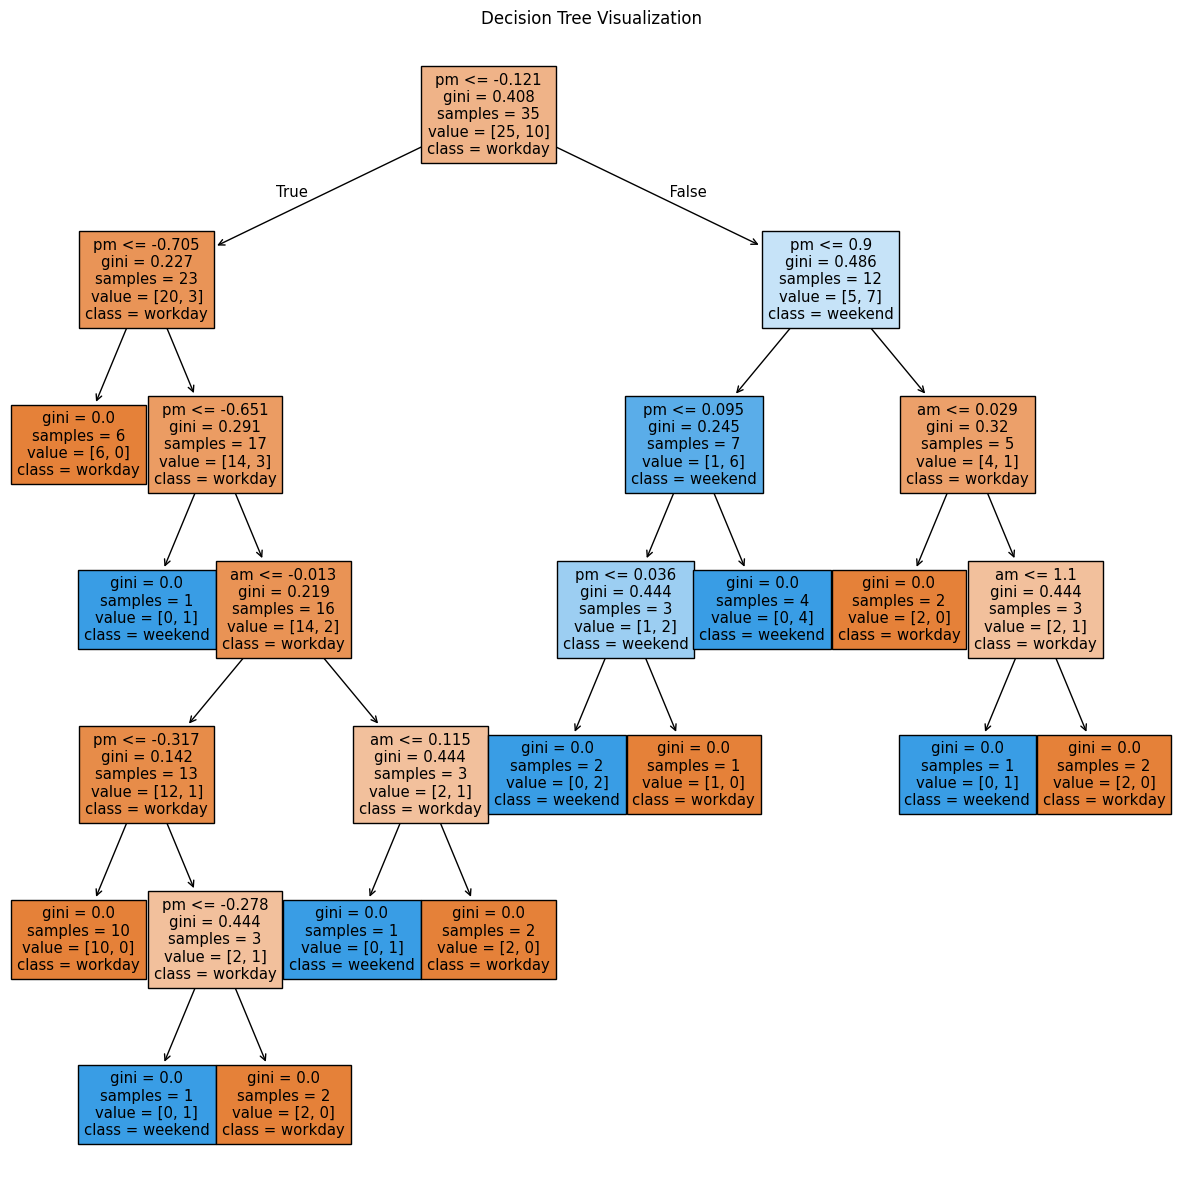

In [30]:
plt.figure(figsize=(15, 15))
plot_tree(best_tree_model, feature_names=['am', 'pm'], class_names=['workday', 'weekend'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

## How many leaves in the visualized tree label days as working days? 15


